In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sb

### Premiére étape 
#### L'algorithme choisi est DEPSO :

In [2]:
data=np.loadtxt('DE-PSO_garcia-nieto_noiseless/DE-PSO/data_f1/bbobexp_f1_DIM10.tdat',comments='%',skiprows=1)

In [3]:
evals=data[:,0]

In [4]:
print(evals)

[1.000e+00 2.000e+00 3.000e+00 ... 7.943e+03 8.912e+03 1.000e+04]


In [5]:
best_noise_free = data[:,2]

In [6]:
print(best_noise_free)

[9.21168253e+01 9.21168253e+01 9.21168253e+01 ... 5.51110400e-07
 7.90097730e-08 8.52350013e-09]


In [7]:
runs=[]
current_run=[]

with open("DE-PSO_garcia-nieto_noiseless/DE-PSO/data_f1/bbobexp_f1_DIM10.tdat") as f :
    for line in f:
        if line.startswith('%'):
            continue
        parts=line.split()
        values=list(map(float,parts))
        eval_num=values[0]
        if eval_num==1 and len(current_run)>0:
            runs.append(np.array(current_run))
            current_run=[]
        current_run.append(values)

if current_run:
    runs.append(np.array(current_run))

In [8]:
print(f'Nombre de runs : ',len(runs))

Nombre de runs :  15


#### Visualiser et analyser l’exécution d’un run (une instance)

In [10]:
run = runs[0]
function_evaluation = run[:,0]
noise_free_fitness=run[:,1]
best_noise_free_fitness = run[:,2]
measured_fitness=run[:,3]
best_measured_fitness=run[:,4]

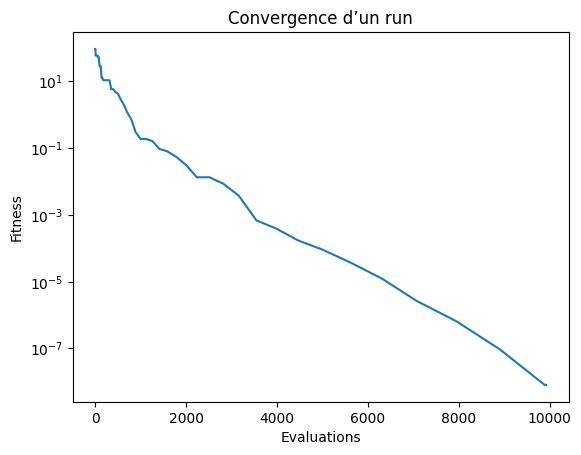

In [13]:
plt.plot(function_evaluation, best_noise_free_fitness)
plt.yscale("log")
plt.title("Convergence d’un run")
plt.xlabel("Evaluations")
plt.ylabel("Fitness")
plt.savefig('Convergence d’un run.png')
plt.show()

### Stabilité : Fluctuations dans measured fitness 

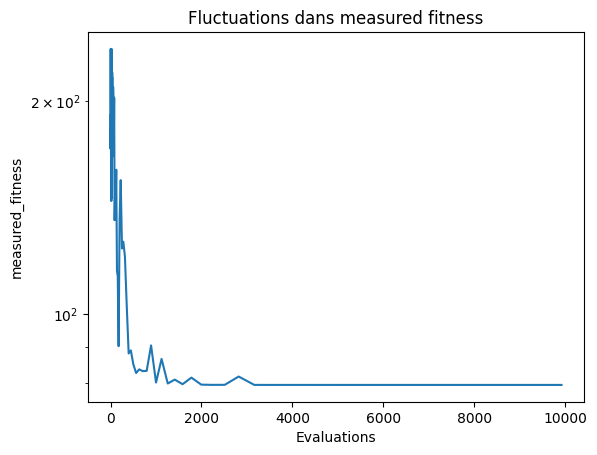

In [12]:
plt.plot(function_evaluation, measured_fitness)
plt.yscale("log")
plt.title("Fluctuations dans measured fitness")
plt.xlabel("Evaluations")
plt.ylabel("measured_fitness")
plt.savefig('Fluctuations dans measured fitness.png')
plt.show()

#### Imapct du bruit :

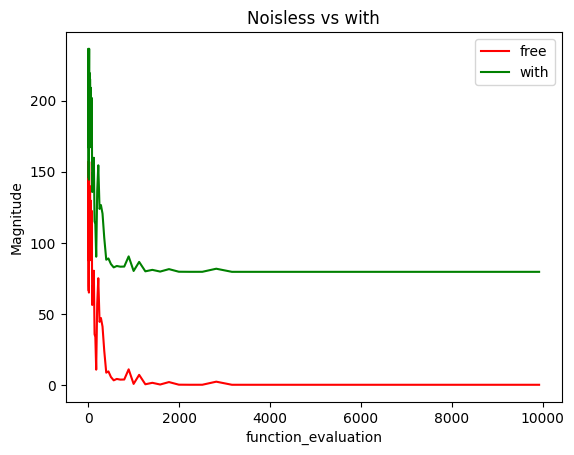

In [14]:
plt.plot(function_evaluation, noise_free_fitness, color='r', label='free')
plt.plot(function_evaluation, measured_fitness, color='g', label='with')

plt.xlabel("function_evaluation")
plt.ylabel("Magnitude")
plt.title("Noisless vs with")
plt.legend()
plt.savefig("Imapct du bruit_normal.png")
plt.show()

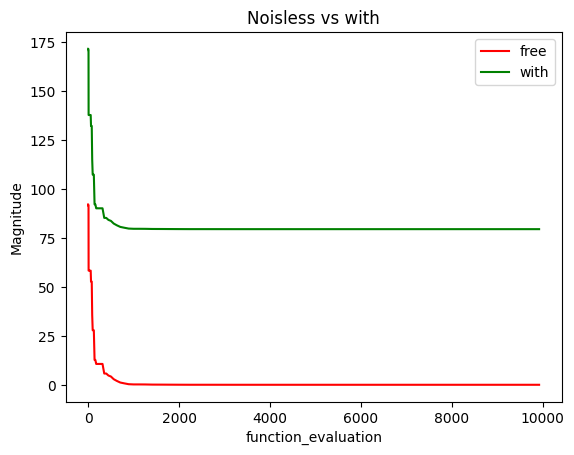

In [15]:
plt.plot(function_evaluation, best_noise_free_fitness, color='r', label='free')
plt.plot(function_evaluation, best_measured_fitness, color='g', label='with')

plt.xlabel("function_evaluation")
plt.ylabel("Magnitude")
plt.title("Noisless vs with")
plt.legend()
plt.savefig("Imapct du bruit_best.png")
plt.show()

what we can say from this is that the functions are noisless, the only difference between the column of noise-free and the column of measured ifs the Fopt value, other than that they are the same.

### Plusieurs runs

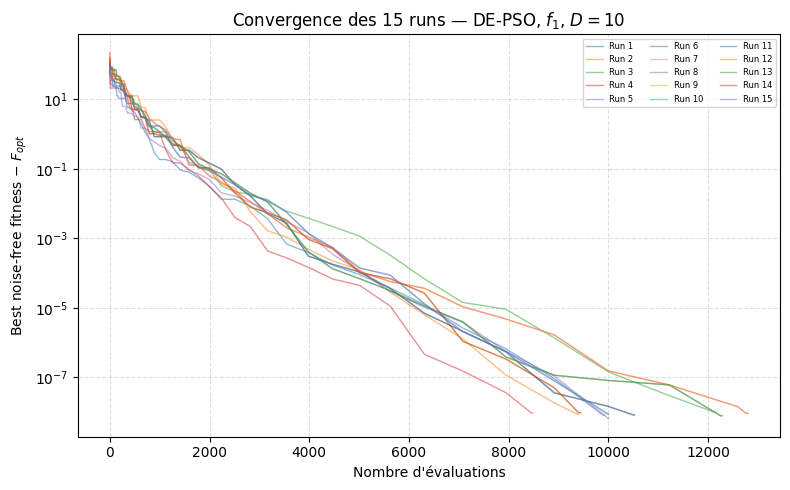


Fitness final (best noise-free) sur les 15 runs :
  Min    = 6.486e-09
  Médiane= 8.524e-09
  Max    = 9.752e-09
  Std    = 8.289e-10


In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
 
for i, r in enumerate(runs):ax.plot(r[:, 0], r[:, 2],alpha=0.5, lw=1.0,label=f'Run {i+1}')
 
ax.set_yscale('log')
ax.set_xlabel("Nombre d'évaluations")
ax.set_ylabel("Best noise-free fitness − $F_{opt}$")
ax.set_title(f"Convergence des {len(runs)} runs — DE-PSO, $f_1$, $D=10$")
ax.legend(fontsize=6, ncol=3, loc='upper right')
ax.grid(True, which='both', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("Multi_runs_convergence.png", dpi=150)
plt.show()

finals = [r[-1, 2] for r in runs]
print(f"\nFitness final (best noise-free) sur les {len(runs)} runs :")
print(f"  Min    = {np.min(finals):.3e}")
print(f"  Médiane= {np.median(finals):.3e}")
print(f"  Max    = {np.max(finals):.3e}")
print(f"  Std    = {np.std(finals):.3e}")

### Aggrégation des runs 

In [17]:
N_GRID = 500
grid = np.logspace(0, 4, N_GRID)

In [19]:
interpolated = []
for r in runs:
    evals = r[:, 0]
    best  = r[:, 2]
    interp = np.interp(grid, evals, best,left=best[0],right=best[-1])
    interpolated.append(interp)
 
matrix = np.array(interpolated)
median = np.median(matrix, axis=0)
p25    = np.percentile(matrix, 25, axis=0)
p75    = np.percentile(matrix, 75, axis=0)
p10    = np.percentile(matrix, 10, axis=0)
p90    = np.percentile(matrix, 90, axis=0)

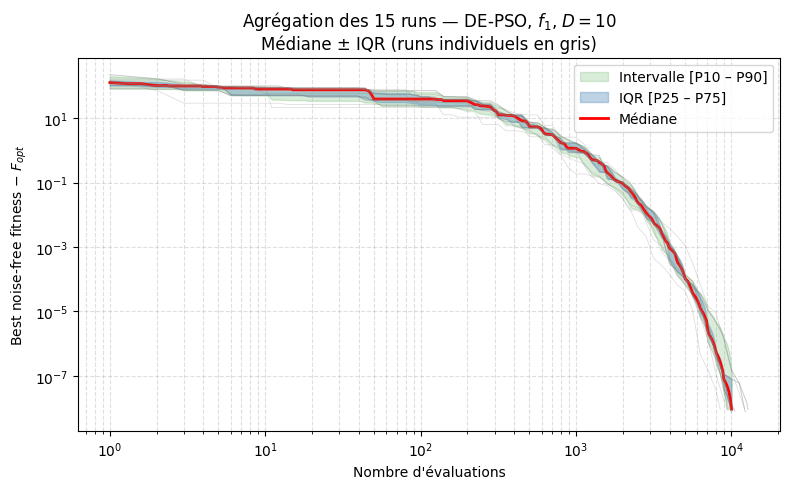


Agrégation à t = 10 000 évaluations :
  Médiane = 9.460e-09
  P25     = 8.524e-09
  P75     = 8.047e-08


In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(grid, p10, p90,alpha=0.15, color='green',label='Intervalle [P10 – P90]')
ax.fill_between(grid, p25, p75,alpha=0.35, color='steelblue',label='IQR [P25 – P75]')
ax.plot(grid, median,color='red', lw=2.0,label='Médiane')
for r in runs:
    ax.plot(r[:, 0], r[:, 2],color='gray', lw=0.6, alpha=0.25)
 
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("Nombre d'évaluations")
ax.set_ylabel("Best noise-free fitness − $F_{opt}$")
ax.set_title(f"Agrégation des {len(runs)} runs — DE-PSO, $f_1$, $D=10$\n"
             f"Médiane ± IQR (runs individuels en gris)")
ax.legend(loc='upper right')
ax.grid(True, which='both', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("Agregation_runs.png", dpi=150)
plt.show()

print("\nAgrégation à t = 10 000 évaluations :")
print(f"  Médiane = {median[-1]:.3e}")
print(f"  P25     = {p25[-1]:.3e}")
print(f"  P75     = {p75[-1]:.3e}")